# Module 01 — MLP + Backpropagation
### *Stack the lines, and learn them with the chain rule.*

Module 00 ended at a wall: **XOR** is not linearly separable, so no single perceptron
can ever learn it. **Rumelhart, Hinton & Williams (1986)** showed the escape — insert a
*hidden layer* of neurons in between, and train every weight by pushing the error
**backward** through the network with the chain rule. That algorithm is
**backpropagation**, and it is still exactly what trains today's largest models.

This notebook rebuilds the idea cell by cell: the forward pass, the loss, the backward
pass *derived by hand*, then XOR finally solved, a bent boundary around two moons, and
**MNIST at ≥95%**. Every inline result is checked against the canonical
[`python/mlp.py`](python/mlp.py), and the closing section cross-checks our hand-derived
gradients against PyTorch, TensorFlow, and Keras.

> **Run it interactively:** `jupyter lab topics/01-mlp-backprop/notebook.ipynb`
> **Confirm it executes clean:** `jupyter nbconvert --to notebook --execute --inplace topics/01-mlp-backprop/notebook.ipynb`

## 1. The intuition

A perceptron draws **one line**. XOR needs two: the positive class $\{(0,1),(1,0)\}$ sits
*between* the two negative corners, and no single straight cut separates it.

The fix is to stop asking one neuron to do everything. Give a **hidden layer** of neurons,
each of which draws its own line and outputs a soft 0/1 (a sigmoid). Those hidden outputs
are **new, learned features** — a new coordinate system in which the problem *is* linearly
separable — and a final neuron draws one last line in that space. Stack two layers of the
Module-00 unit, learn them together, and the wall falls.

The only new machinery we need is a way to train the *hidden* weights, which have no direct
target. That is what backpropagation provides.

## 2. The math (all of it)

A network with one hidden layer of $h$ units. For an input $x\in\mathbb{R}^2$:

$$z_1 = W_1 x + b_1,\qquad a_1 = \sigma(z_1)\quad(\text{hidden, } h\text{ units})$$
$$z_2 = W_2 a_1 + b_2,\qquad \hat y = a_2 = \sigma(z_2)\quad(\text{output})$$

where $\sigma(z) = 1/(1+e^{-z})$ is the logistic sigmoid. We train with **binary
cross-entropy**, averaged over the $m$ samples:

$$L = -\frac{1}{m}\sum \Big[\, y\log a_2 + (1-y)\log(1-a_2)\,\Big].$$

**Backprop** is just the chain rule, applied output-first. The one fact worth memorizing:
for cross-entropy through a sigmoid the output error collapses to a difference,

$$\frac{\partial L}{\partial z_2} = a_2 - y \;\equiv\; \delta_2.$$

From there every gradient is a local product, using $\sigma'(z) = a(1-a)$:

$$\frac{\partial L}{\partial W_2} = \delta_2\, a_1^\top,\qquad
  \frac{\partial L}{\partial b_2} = \delta_2,$$
$$\delta_1 = (W_2^\top \delta_2)\odot a_1(1-a_1),\qquad
  \frac{\partial L}{\partial W_1} = \delta_1\, x^\top,\qquad
  \frac{\partial L}{\partial b_1} = \delta_1.$$

Then descend: $\theta \leftarrow \theta - \eta\,\partial L/\partial\theta$. That is the
entire algorithm. Everything below is this written out in code.

In [1]:
import math, os, sys
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# Make python/ and tests/ importable whether this notebook is launched from the
# module folder (jupyter lab) or the repo root (headless nbconvert).
for cand in ["python", "tests",
             os.path.join("topics", "01-mlp-backprop", "python"),
             os.path.join("topics", "01-mlp-backprop", "tests")]:
    if os.path.isdir(cand) and cand not in sys.path:
        sys.path.insert(0, cand)

## 3. A deterministic RNG (why bit-exactness matters)

The C implementation ([`c/mlp.c`](c/mlp.c)) and this Python live-or-die on producing the
*same* numbers from the same seed — that is what the agreement test checks. So both roll
the identical 64-bit LCG and draw the initial weights from it in the same order.

In [2]:
_MASK64 = (1 << 64) - 1

class Rng:
    def __init__(self, seed): self.state = seed & _MASK64
    def next_u64(self):
        self.state = (self.state * 6364136223846793005 + 1442695040888963407) & _MASK64
        return self.state
    def uniform(self): return (self.next_u64() >> 11) * (1.0 / 9007199254740992.0)
    def signed(self):  return 2.0 * self.uniform() - 1.0

# sanity: first few draws are deterministic
r = Rng(1)
[round(r.signed(), 4) for _ in range(4)]

[-0.1536, 0.0188, 0.2967, -0.2343]

## 4. The XOR problem — the wall from Module 00

Four points, arithmetic only (no `sin`/`log` in the *data*, so C and Python agree
bit-for-bit). The two classes interleave: notice you cannot separate blue from orange with
a single straight line.

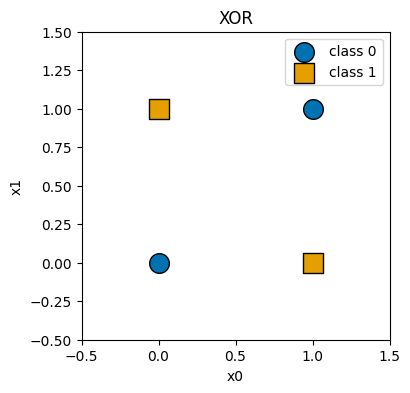

In [3]:
def make_xor():
    X = [[0., 0.], [0., 1.], [1., 0.], [1., 1.]]
    y = [0., 1., 1., 0.]
    return X, y

X, y = make_xor()
Xa = np.array(X)
fig, ax = plt.subplots(figsize=(4, 4))
for cls, color, marker in [(0, "#0072B2", "o"), (1, "#E69F00", "s")]:
    pts = Xa[[i for i in range(4) if y[i] == cls]]
    ax.scatter(pts[:, 0], pts[:, 1], c=color, marker=marker, s=200,
               edgecolor="k", label=f"class {cls}")
ax.set(xlim=(-0.5, 1.5), ylim=(-0.5, 1.5), xlabel="x0", ylabel="x1", title="XOR")
ax.legend(); ax.set_aspect("equal"); plt.show()

## 5. The network: forward pass

A `2 -> h -> 1` sigmoid MLP, written with explicit loops so it reads exactly like the C.
Parameters live in NumPy arrays (so we can gradient-check them), but each computation runs
as plain Python floats in a fixed order.

In [4]:
def sigmoid_scalar(z):
    return 1.0 / (1.0 + math.exp(-z))

class MLP:
    def __init__(self, n_in, n_hidden, rng, scale=1.0):
        self.n_in, self.n_hidden = n_in, n_hidden
        self.W1 = np.zeros((n_hidden, n_in)); self.b1 = np.zeros(n_hidden)
        self.W2 = np.zeros(n_hidden);         self.b2 = np.zeros(1)
        for j in range(n_hidden):
            for k in range(n_in):
                self.W1[j, k] = scale * rng.signed()
        for j in range(n_hidden): self.b1[j] = scale * rng.signed()
        for j in range(n_hidden): self.W2[j] = scale * rng.signed()
        self.b2[0] = scale * rng.signed()

    def forward(self, x0, x1):
        a1 = [0.0] * self.n_hidden
        for j in range(self.n_hidden):
            z1 = float(self.b1[j]) + float(self.W1[j, 0]) * x0 + float(self.W1[j, 1]) * x1
            a1[j] = sigmoid_scalar(z1)
        z2 = float(self.b2[0])
        for j in range(self.n_hidden):
            z2 += float(self.W2[j]) * a1[j]
        return a1, sigmoid_scalar(z2)

    def predict(self, x0, x1):
        _, a2 = self.forward(x0, x1)
        return 1 if a2 >= 0.5 else 0

    def loss(self, X, y):
        n = len(y); total = 0.0
        for i in range(n):
            _, a2 = self.forward(float(X[i][0]), float(X[i][1]))
            yi = float(y[i])
            total += -(yi * math.log(a2) + (1.0 - yi) * math.log(1.0 - a2))
        return total / n

    def backward(self, X, y):
        n = len(y)
        dW1 = np.zeros_like(self.W1); db1 = np.zeros_like(self.b1)
        dW2 = np.zeros_like(self.W2); db2 = np.zeros_like(self.b2)
        for i in range(n):
            x0, x1, yi = float(X[i][0]), float(X[i][1]), float(y[i])
            a1, a2 = self.forward(x0, x1)
            dz2 = a2 - yi                          # BCE through sigmoid
            for j in range(self.n_hidden): dW2[j] += dz2 * a1[j]
            db2[0] += dz2
            for j in range(self.n_hidden):
                da1 = dz2 * float(self.W2[j])
                dz1 = da1 * a1[j] * (1.0 - a1[j])  # sigmoid'
                dW1[j, 0] += dz1 * x0; dW1[j, 1] += dz1 * x1
                db1[j] += dz1
        dW1 /= n; db1 /= n; dW2 /= n; db2 /= n
        return dW1, db1, dW2, db2

    def sgd_step(self, X, y, lr):
        dW1, db1, dW2, db2 = self.backward(X, y)
        self.W1 -= lr * dW1; self.b1 -= lr * db1
        self.W2 -= lr * dW2; self.b2 -= lr * db2

# an untrained net still runs forward — just badly
net = MLP(2, 4, Rng(1), scale=1.0)
[round(net.forward(*p)[1], 3) for p in X]

[0.509, 0.489, 0.485, 0.464]

## 6. Is the backward pass correct? The gradient check

Hand-derived gradients are exactly where bugs hide. The antidote: compare the analytic
gradient to a **numerical** one — nudge each weight by $\pm h$, watch the loss, and estimate
$\partial L/\partial\theta \approx [L(\theta+h) - L(\theta-h)] / 2h$. If the two agree to a
`rel_error` around $10^{-7}$, the backward pass is right. This check is the reason we can
trust everything downstream — and it is the load-bearing exercise of the assignment.

In [5]:
from check_utils import eval_numerical_gradient, rel_error

net = MLP(2, 4, Rng(1), scale=1.0)
dW1, db1, dW2, db2 = net.backward(X, y)
for name, P, analytic in [("W1", net.W1, dW1), ("b1", net.b1, db1),
                          ("W2", net.W2, dW2), ("b2", net.b2, db2)]:
    numeric = eval_numerical_gradient(lambda _: net.loss(X, y), P)
    err = rel_error(analytic, numeric)
    print(f"d{name:2s}  rel_error = {err:.2e}  {'ok' if err < 1e-6 else 'FAIL'}")
    assert err < 1e-6

dW1  rel_error = 1.03e-07  ok
db1  rel_error = 2.95e-09  ok
dW2  rel_error = 5.62e-10  ok
db2  rel_error = 4.23e-10  ok


## 7. Train it — XOR solved

Full-batch gradient descent, 20 000 steps. Watch the loss fall and the accuracy hit
**1.000** — the exact thing a single perceptron could never do.

final loss = 0.000852   accuracy = 1.000


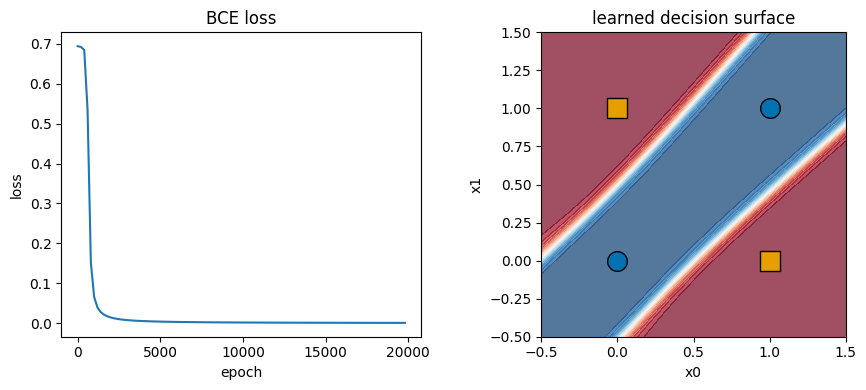

In [6]:
XOR_SEED, N_HIDDEN, INIT_SCALE, XOR_LR, XOR_EPOCHS = 1, 4, 1.0, 0.5, 20000

net = MLP(2, N_HIDDEN, Rng(XOR_SEED), scale=INIT_SCALE)
hist = []
for e in range(XOR_EPOCHS):
    net.sgd_step(X, y, XOR_LR)
    if e % 200 == 0:
        hist.append(net.loss(X, y))
acc = sum(net.predict(*X[i]) == y[i] for i in range(4)) / 4
print(f"final loss = {net.loss(X, y):.6f}   accuracy = {acc:.3f}")

# loss curve + learned decision surface
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 4))
a1.plot(np.arange(len(hist)) * 200, hist); a1.set(xlabel="epoch", ylabel="loss", title="BCE loss")
gx, gy = np.meshgrid(np.linspace(-0.5, 1.5, 120), np.linspace(-0.5, 1.5, 120))
gz = np.array([[net.forward(float(a), float(b))[1] for a, b in zip(rx, ry)]
               for rx, ry in zip(gx, gy)])
a2.contourf(gx, gy, gz, levels=20, cmap="RdBu_r", alpha=0.7)
for cls, color, marker in [(0, "#0072B2", "o"), (1, "#E69F00", "s")]:
    pts = Xa[[i for i in range(4) if y[i] == cls]]
    a2.scatter(pts[:, 0], pts[:, 1], c=color, marker=marker, s=200, edgecolor="k")
a2.set(title="learned decision surface", xlabel="x0", ylabel="x1"); a2.set_aspect("equal")
plt.tight_layout(); plt.show()

xor_inline = (net.loss(X, y), acc, float(net.W1.sum()+net.b1.sum()+net.W2.sum()+net.b2.sum()))

### Optional: poke at it

If `ipywidgets` is installed, drag the learning rate and hidden width and re-train. (The
notebook runs fine without it — this cell is guarded.)

In [7]:
try:
    from ipywidgets import interact, IntSlider, FloatSlider

    def _demo(n_hidden=4, lr=0.5, epochs=4000):
        m = MLP(2, n_hidden, Rng(1), 1.0)
        for _ in range(epochs): m.sgd_step(X, y, lr)
        acc = sum(m.predict(*X[i]) == y[i] for i in range(4)) / 4
        print(f"acc={acc:.2f}  loss={m.loss(X, y):.4f}")

    interact(_demo,
             n_hidden=IntSlider(value=4, min=1, max=8),
             lr=FloatSlider(value=0.5, min=0.05, max=2.0, step=0.05),
             epochs=IntSlider(value=4000, min=500, max=20000, step=500))
except Exception as e:
    print(f"ipywidgets unavailable ({type(e).__name__}) — skipping the interactive demo")

interactive(children=(IntSlider(value=4, description='n_hidden', max=8, min=1), FloatSlider(value=0.5, descrip…

## 8. Two moons — a boundary that bends

XOR is the *smallest* nonlinear problem. Two interleaving half-moons are a prettier one:
still impossible for a line, easy for a hidden layer, which learns a curved boundary that
threads between them. Here the output is a **softmax** over 2 classes — the batched,
vectorized twin of everything above (see `MLPVec` in `python/mlp.py`). We snapshot the
boundary as it bends into place.

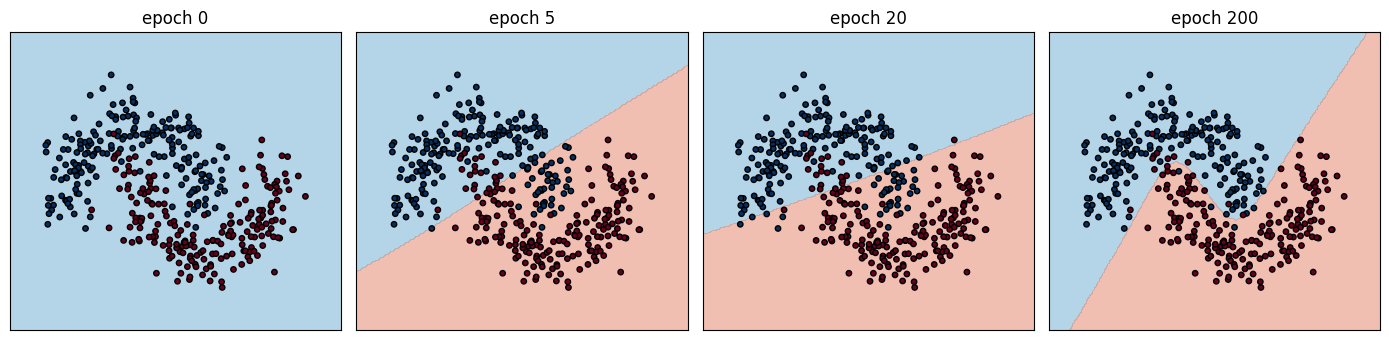

two-moons test-set accuracy: 0.97


In [8]:
import mlp as canon  # the canonical module: MLPVec, make_two_moons, train_minibatch

Xm, ym = canon.make_two_moons(n=400, noise=0.2, seed=0)
model = canon.MLPVec(2, 16, 2, seed=0)

gx, gy = np.meshgrid(np.linspace(Xm[:,0].min()-.5, Xm[:,0].max()+.5, 200),
                     np.linspace(Xm[:,1].min()-.5, Xm[:,1].max()+.5, 200))
grid = np.c_[gx.ravel(), gy.ravel()]
snaps = [0, 5, 20, 200]
fig, axes = plt.subplots(1, len(snaps), figsize=(14, 3.5))
done = 0
for ax, target in zip(axes, snaps):
    canon.train_minibatch(model, Xm, ym, lr=0.5, epochs=target - done, batch_size=32, seed=0)
    done = target
    zz = model.predict(grid).reshape(gx.shape)
    ax.contourf(gx, gy, zz, levels=1, cmap="RdBu_r", alpha=0.5)
    ax.scatter(Xm[:,0], Xm[:,1], c=ym, cmap="RdBu_r", edgecolor="k", s=15)
    ax.set(title=f"epoch {target}"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()
print("two-moons test-set accuracy:", canon.run_two_moons())

## 9. Scale to MNIST — the real thing

Same network, bigger: `784 -> 128 -> 10`, softmax over the ten digits. Plain mini-batch SGD,
no tricks (those are Module 02). It crosses **95%** within a couple of epochs and settles
near **97–98%** — real handwritten digits, learned from scratch.

MNIST test accuracy = 0.9704


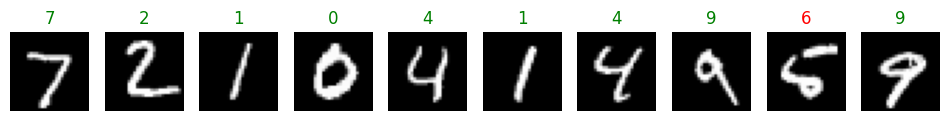

In [9]:
Xtr, ytr, Xte, yte = canon._load_mnist()
mnist = canon.MLPVec(784, 128, 10, seed=0)
canon.train_minibatch(mnist, Xtr, ytr, lr=0.5, epochs=8, batch_size=64, seed=0)
mnist_acc = float((mnist.predict(Xte) == yte).mean())
print(f"MNIST test accuracy = {mnist_acc:.4f}")
assert mnist_acc >= 0.95, mnist_acc

# show a few predictions
pred = mnist.predict(Xte[:10])
fig, axes = plt.subplots(1, 10, figsize=(12, 1.6))
for ax, img, p, t in zip(axes, Xte[:10], pred, yte[:10]):
    ax.imshow(img.reshape(28, 28), cmap="gray"); ax.axis("off")
    ax.set_title(f"{p}", color=("green" if p == t else "red"))
plt.show()

## 10. Verify against the canonical `mlp.py`

The teaching code above must not drift from the source of truth. We re-run the canonical
`run_xor()` and confirm our inline XOR result matches to near double precision.

In [10]:
def _close(a, b, tol=1e-12): return abs(a - b) <= tol * max(1.0, abs(a), abs(b))

fp = dict(canon.run_xor())
print(f"{'':8s}{'inline':>22s}{'canonical':>22s}")
for lab, val in [("loss", xor_inline[0]), ("acc", xor_inline[1]), ("wsum", xor_inline[2])]:
    print(f"{lab:8s}{val:22.15g}{fp[lab]:22.15g}")
    assert _close(val, fp[lab]), lab
print("OK — inline results match python/mlp.py")

                        inline             canonical
loss      0.000852434525469214  0.000852434525469214
acc                          1                     1
wsum          12.8591995818131      12.8591995818131
OK — inline results match python/mlp.py


## 11. Framework mirrors: PyTorch, TensorFlow, Keras

From-scratch taught the mechanism; this section teaches the **frameworks** — how the same idea
is written in PyTorch, TensorFlow, and Keras (principles, not production code) — and doubles as
the **check**: PyTorch validates our hand-derived gradients to machine precision; TensorFlow
and Keras rebuild the same idea idiomatically and must reach the same ballpark accuracy.

### 11.1 PyTorch — a strict check of our gradients

Load **our** initial weights into an identical `float64` net, run one forward/backward with
autograd, and compare PyTorch's gradients to our hand-derived ones. They agree to ~$10^{-15}$
— proof the backward pass is exactly right.

In [11]:
import torch

net = MLP(2, 4, Rng(1), 1.0)
dW1, db1, dW2, db2 = net.backward(X, y)

tX = torch.tensor(X, dtype=torch.float64)
ty = torch.tensor(y, dtype=torch.float64)
W1 = torch.tensor(net.W1, dtype=torch.float64, requires_grad=True)
b1 = torch.tensor(net.b1, dtype=torch.float64, requires_grad=True)
W2 = torch.tensor(net.W2, dtype=torch.float64, requires_grad=True)
b2 = torch.tensor(net.b2, dtype=torch.float64, requires_grad=True)
a1 = torch.sigmoid(tX @ W1.T + b1)
a2 = torch.sigmoid(a1 @ W2 + b2)
loss = -(ty * torch.log(a2) + (1 - ty) * torch.log(1 - a2)).mean()
loss.backward()

for name, ours, t in [("W1", dW1, W1), ("b1", db1, b1), ("W2", dW2, W2), ("b2", db2, b2)]:
    err = rel_error(ours, t.grad.numpy())
    print(f"d{name:2s}  rel_error = {err:.2e}")
    assert err < 1e-12
print(f"loss: ours={net.loss(X,y):.15g}  torch={loss.item():.15g}")

dW1  rel_error = 1.41e-15
db1  rel_error = 1.34e-15
dW2  rel_error = 4.75e-16
db2  rel_error = 0.00e+00
loss: ours=0.694016460383942  torch=0.694016460383942


### 11.2 TensorFlow — idiomatic, with a `GradientTape`

Lower-level TF: define the same 2→16→2 net and train two-moons by hand with a gradient tape
and Adam. Different code, same result — a boundary that separates the moons.

In [12]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")
import tensorflow as tf

Xt = tf.constant(Xm, tf.float32); yt = tf.constant(ym, tf.int32)
w1 = tf.Variable(tf.random.normal([2, 16], stddev=0.5, seed=0))
c1 = tf.Variable(tf.zeros([16]))
w2 = tf.Variable(tf.random.normal([16, 2], stddev=0.5, seed=1))
c2 = tf.Variable(tf.zeros([2]))
opt = tf.keras.optimizers.Adam(0.05)

for step in range(400):
    with tf.GradientTape() as tape:
        h = tf.sigmoid(Xt @ w1 + c1)
        logits = h @ w2 + c2
        loss = tf.reduce_mean(
            tf.nn.sparse_softmax_cross_entropy_with_logits(labels=yt, logits=logits))
    grads = tape.gradient(loss, [w1, c1, w2, c2])
    opt.apply_gradients(zip(grads, [w1, c1, w2, c2]))

h = tf.sigmoid(Xt @ w1 + c1)
acc = float(tf.reduce_mean(tf.cast(
    tf.argmax(h @ w2 + c2, axis=1, output_type=tf.int32) == yt, tf.float32)))
print(f"TensorFlow two-moons accuracy = {acc:.3f}")
assert acc >= 0.90

TensorFlow two-moons accuracy = 0.965


### 11.3 Keras — the modern relaxation

The high-level API: describe the layers, `compile`, `fit`. Everything we wrote by hand —
the loops, the chain rule, the SGD step — is now three lines. It reaches ≥95% on MNIST, the
same bar our from-scratch net cleared.

In [13]:
import keras
from keras import layers

model = keras.Sequential([
    keras.Input((784,)),
    layers.Dense(128, activation="sigmoid"),
    layers.Dense(10, activation="softmax"),
])
model.compile(optimizer=keras.optimizers.Adam(0.002),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.fit(Xtr, ytr, epochs=5, batch_size=128, verbose=0)
keras_acc = model.evaluate(Xte, yte, verbose=0)[1]
print(f"Keras MNIST accuracy = {keras_acc:.4f}")
assert keras_acc >= 0.95

Keras MNIST accuracy = 0.9685


---
### What's next

The MLP can now learn any of these toy and small-real problems — but training it took
hand-tuned learning rates and it uses saturating sigmoids that slow learning. **Module 02 —
Training toolkit** fixes exactly that: better activations (tanh, ReLU), principled
initialization (Xavier/He), momentum → RMSProp → Adam, and regularization. Same MLP, far
better training — and the first appearance of the shared `nanograd` library.

*Next: [Training toolkit →](../02-training-toolkit/)*